In [5]:
! apt-get update
! apt-get install -y openjdk-11-jdk-headless -qq > /dev/null

! pip install pyspark -q

! pip install pandas numpy matplotlib seaborn scikit-learn -q

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [6]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, lower, trim, regexp_replace, when,
    countDistinct, count, avg, max, min
)
from pyspark.sql.types import StringType
import warnings
warnings.filterwarnings('ignore')

# Create Spark session
spark = SparkSession.builder \
    .appName("MOOCSentimentAnalysis") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "2g") \
    .config("spark.sql.shuffle.partitions", 100) \
    .getOrCreate()

# Suppress Spark verbose logging
spark.sparkContext.setLogLevel("ERROR")

print("✅ Spark Session Initialized")
print(f"Spark version: {spark.version}")

✅ Spark Session Initialized
Spark version: 4.0.2


In [7]:
# This cell is only needed when running in Google Colab.
# It lets you upload reviews.csv interactively.
# If running locally/Jupyter, skip this cell and place reviews.csv
# in the same folder as this notebook (or update the path below).
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    print("Not running in Google Colab — skipping upload widget.")
    print("Make sure reviews.csv is available at the expected path.")


# Loading the data

In [8]:
import os

file_path = "reviews.csv"

print(f"Loading data from: {file_path}")

try:
    # Load CSV into Spark DataFrame
    df_raw = spark.read.csv(
        file_path,
        header=True,
        inferSchema=True,
        encoding='utf-8'
    )
    print(f"✅ Data loaded successfully!")

except FileNotFoundError:
    print(f"❌ File not found: {file_path}")
    print("Please upload the file or adjust the path")


Loading data from: reviews.csv
✅ Data loaded successfully!


# ** exploring the data**

In [9]:
from pyspark.sql.functions import col, count, when, length, min, avg, max

# Safe cast: only rows where Label is exactly "1"–"5" get an int; others → NULL
df = df_raw.withColumn(
    "Label",
    when(col("Label").rlike("^[1-5]$"), col("Label").cast("int")).otherwise(None)
)

print("="*70)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*70)

# 1. Shape
total = df.count()
print(f"\n1️⃣  Dataset Shape:")
print(f"   Total reviews : {total:,}")
print(f"   Total columns : {len(df.columns)}")

# 2. Schema
print("\n2️⃣  Column Names & Data Types:")
df.printSchema()

# 3. First 5 rows
print("\n3️⃣  First 5 Reviews (Full Content):")
df.show(5, truncate=False)

# 4. Malformed / missing check
print("\n4️⃣  Missing / Malformed Values Check:")
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

print("   Sample malformed rows (Label is NULL):")
df.filter(col("Label").isNull()).show(5, truncate=False)

# 5. Clean dataset
df_clean = df.filter(col("Label").isNotNull() & col("Review").isNotNull())
clean_count = df_clean.count()
print(f"\n   ✅ Clean rows : {clean_count:,}  |  🗑️  Dropped : {total - clean_count:,}")

# 6. Basic statistics
print("\n5️⃣  Basic Statistics (clean data):")
df_clean.describe().show()

# 7. Label distribution
print("\n6️⃣  Label Distribution:")
df_clean.groupBy("Label").count().orderBy("Label") \
    .withColumn("pct%", (col("count") / clean_count * 100).cast("decimal(5,2)")) \
    .show()

# 8. Text length stats
print("\n7️⃣  Review Text Length Statistics:")
df_clean.withColumn("text_len", length(col("Review"))) \
    .agg(
        min("text_len").alias("Min"),
        avg("text_len").alias("Avg"),
        max("text_len").alias("Max")
    ).show()

# 9. Sample reviews per label
print("\n8️⃣  Sample Reviews by Label:")
for lbl in [1, 3, 5]:
    print(f"\n   Label {lbl} ⭐:")
    df_clean.filter(col("Label") == lbl).select("Review", "Label").limit(2).show(truncate=False)

EXPLORATORY DATA ANALYSIS (EDA)

1️⃣  Dataset Shape:
   Total reviews : 107,018
   Total columns : 3

2️⃣  Column Names & Data Types:
root
 |-- Id: integer (nullable = true)
 |-- Review: string (nullable = true)
 |-- Label: integer (nullable = true)


3️⃣  First 5 Reviews (Full Content):
+---+-------------------------------------------------------------------------------------------------------------------------+-----+
|Id |Review                                                                                                                   |Label|
+---+-------------------------------------------------------------------------------------------------------------------------+-----+
|0  |good and interesting                                                                                                     |5    |
|1  |This class is very helpful to me. Currently, I'm still learning this class which makes up a lot of basic music knowledge.|5    |
|2  |like!Prof and TAs are helpful and th

# Cleaning

In [10]:
from pyspark.sql.functions import col, regexp_replace, lower, trim, length, min, avg, max

print("\n" + "="*70)
print("TEXT CLEANING & PREPROCESSING")
print("="*70)

def clean_text(text_col):
    """Applies cleaning transformations to a Spark column (not a Python string)."""
    text_col = regexp_replace(text_col, r'http\S+|www\S+|https\S+', '')  # Remove URLs
    text_col = regexp_replace(text_col, r'\S+@\S+', '')                   # Remove emails
    text_col = lower(text_col)                                             # Lowercase
    text_col = regexp_replace(text_col, r'[^a-z0-9\s]', '')              # Remove punctuation
    text_col = regexp_replace(text_col, r'\s+', ' ')                      # Collapse spaces
    text_col = trim(text_col)                                              # Strip edges
    return text_col

print("\n📝 Applying cleaning transformations...")

df_clean = df_clean.withColumn(          # ← uses df_clean from previous cell
    "review_clean",
    clean_text(col("Review"))
)

print("✅ Cleaning complete!")

# Show before & after
print("\n📊 Before & After Cleaning:")
df_clean.select(
    col("Review").alias("Original"),
    col("review_clean").alias("Cleaned"),
    col("Label").alias("Label")
).limit(5).show(truncate=False)

# Cleaned text length stats
print("\n🔍 Cleaned Text Statistics:")
df_clean.withColumn("cleaned_length", length(col("review_clean"))).agg(
    min("cleaned_length").alias("Min"),
    avg("cleaned_length").alias("Avg"),
    max("cleaned_length").alias("Max")
).show()

# Drop reviews that became empty after cleaning
df_clean = df_clean.filter(length(col("review_clean")) > 0)
print(f"\n✅ Reviews remaining after cleaning: {df_clean.count():,}")


TEXT CLEANING & PREPROCESSING

📝 Applying cleaning transformations...
✅ Cleaning complete!

📊 Before & After Cleaning:
+-------------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------+-----+
|Original                                                                                                                 |Cleaned                                                                                                              |Label|
+-------------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------+-----+
|good and interesting                                                                                                     |good and inte

In [11]:
print("\n" + "="*70)
print("FEATURE EXTRACTION - TF-IDF")
print("="*70)

from pyspark.ml.feature import HashingTF, IDF, Tokenizer, StopWordsRemover

print("\n1️⃣  Tokenizing text (splitting into words)...")

# Step 1: Tokenize (split text into words)
tokenizer = Tokenizer(
    inputCol="review_clean",
    outputCol="tokens"
)
df_tokens = tokenizer.transform(df_clean)

print("✅ Tokenization complete")
print("\n   Example tokens:")
df_tokens.select("review_clean", "tokens").limit(3).show(truncate=False)

# Step 2: Remove stopwords
print("\n2️⃣  Removing stopwords (common words like 'the', 'a', 'is')...")

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens",
    stopWords=StopWordsRemover.loadDefaultStopWords("english")
)
df_filtered = remover.transform(df_tokens)

print("✅ Stopword removal complete")
print("\n   Example filtered tokens:")
df_filtered.select("tokens", "filtered_tokens").limit(3).show(truncate=False)

# Step 3: Convert tokens to TF-IDF features
print("\n3️⃣  Computing TF-IDF vectors...")

# HashingTF: Quick conversion using hashing
# numFeatures: How many words to track (vocabulary size)
# Higher = more detailed, slower; Lower = faster, less detail
# 1000 is a good balance for this task
hashing_tf = HashingTF(
    inputCol="filtered_tokens",
    outputCol="raw_features",
    numFeatures=1000  # Create 1000-dimensional vectors
)
df_tf = hashing_tf.transform(df_filtered)

print("✅ TF computed")

# IDF: Scale by inverse document frequency
idf = IDF(
    inputCol="raw_features",
    outputCol="features",
    minDocFreq=5  # Ignore words appearing in <5 documents
)
idf_model = idf.fit(df_tf)
df_features = idf_model.transform(df_tf)

print("✅ IDF computed")

print("\n   TF-IDF Feature Vector Example:")
df_features.select("review_clean", "features").limit(2).show(truncate=False)

print(f"\n   Feature vector dimension: 1000")
print(f"   Meaning: Each review is represented by 1000 numbers")



FEATURE EXTRACTION - TF-IDF

1️⃣  Tokenizing text (splitting into words)...
✅ Tokenization complete

   Example tokens:
+---------------------------------------------------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------+
|review_clean                                                                                                         |tokens                                                                                                                                      |
+---------------------------------------------------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------+
|good and interesting                                                                           

# Creating sentiment labels

In [12]:
from pyspark.sql.functions import col, when

print("\n" + "="*70)
print("LABEL CREATION (Label → Sentiment)")
print("="*70)

# Create binary labels: 1-3 = negative (0), 4-5 = positive (1)
df_labeled = df_features.withColumn(
    "label",
    when(col("Label") >= 4, 1).otherwise(0)   # ✅ "rating" → "Label"
)

print("✅ Labels created")

# Check label distribution
total = df_labeled.count()

print("\n📊 Label Distribution:")
label_dist = df_labeled.groupBy("label").count().orderBy("label") \
    .withColumn("percentage", (col("count") / total * 100).cast("decimal(5,2)"))
label_dist.show()

print("\n💡 Interpretation:")
print("   Label 0 = Negative (ratings 1-3)")
print("   Label 1 = Positive (ratings 4-5)")


LABEL CREATION (Label → Sentiment)
✅ Labels created

📊 Label Distribution:
+-----+-----+----------+
|label|count|percentage|
+-----+-----+----------+
|    0| 9301|      8.80|
|    1|96348|     91.20|
+-----+-----+----------+


💡 Interpretation:
   Label 0 = Negative (ratings 1-3)
   Label 1 = Positive (ratings 4-5)


# Spliting the data

In [13]:
print("\n" + "="*70)
print("TRAIN-TEST SPLIT")
print("="*70)

# Split 80-20
train_data, test_data = df_labeled.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("✅ Data split complete")

print(f"\n📊 Data Distribution:")
print(f"   Training samples: {train_data.count():,} (80%)")
print(f"   Test samples: {test_data.count():,} (20%)")

# Check label distribution in train/test
print(f"\n📊 Label distribution in Training set:")
train_data.groupBy("label").count().orderBy("label").show()

print(f"\n📊 Label distribution in Test set:")
test_data.groupBy("label").count().orderBy("label").show()

# Verify no overlap (should always be true with random split)
print(f"\n✅ Training and test sets are separate (no data leakage)")


TRAIN-TEST SPLIT
✅ Data split complete

📊 Data Distribution:
   Training samples: 84,474 (80%)
   Test samples: 21,175 (20%)

📊 Label distribution in Training set:
+-----+-----+
|label|count|
+-----+-----+
|    0| 7417|
|    1|77057|
+-----+-----+


📊 Label distribution in Test set:
+-----+-----+
|label|count|
+-----+-----+
|    0| 1884|
|    1|19291|
+-----+-----+


✅ Training and test sets are separate (no data leakage)


In [60]:
pos_count = train_data.filter(col("label") == 1).count()
neg_count = train_data.filter(col("label") == 0).count()
total_count = train_data.count()

# Add the weight column
train_data = train_data.withColumn(
    "classWeightCol",
    when(col("label") == 1, total_count / (2 * pos_count))
    .otherwise(total_count / (2 * neg_count))
)


# Model 1

In [71]:
from pyspark.ml.classification import LogisticRegression

print("\n" + "="*70)
print("MODEL TRAINING - LOGISTIC REGRESSION")
print("="*70)


# Initialize Logistic Regression model
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="classWeightCol",
    maxIter=100,
    regParam=0.1,
    elasticNetParam=0.0
)


print("\n⚙️ Training Logistic Regression model...")
# Train the model
lr_model = lr.fit(train_data)
print("✅ Model trained successfully!")

print("\n" + "="*70)
print("MAKE PREDICTIONS")
print("="*70)

print("\n🔮 Generating predictions on test set...")

predictions_lr = lr_model.transform(test_data)

print("✅ Predictions generated!")

# Show sample predictions
print("\n📊 Sample Predictions:")
predictions_lr.select(
    "Review", # Original review content
    "Label",  # Original 1-5 star rating
    "label",  # Binary label (0=negative, 1=positive)
    "prediction",
    "probability"
).limit(10).show(truncate=False)



MODEL TRAINING - LOGISTIC REGRESSION

⚙️ Training Logistic Regression model...
✅ Model trained successfully!

MAKE PREDICTIONS

🔮 Generating predictions on test set...
✅ Predictions generated!

📊 Sample Predictions:
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+-----+----------+----------------------------------------+
|Review                                                                                                                                                                                                                     

# METRICS:

In [70]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import ParamGridBuilder
from pyspark.ml.tuning import CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="classWeightCol",
    maxIter=100
)

paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.05, 0.07, 0.1, 0.2, 0.3]) \
    .addGrid(lr.elasticNetParam, [0.0,0.01, 0.02]) \
    .build()

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"  # good for imbalanced data
)

crossval = CrossValidator(
    estimator=lr,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=5  # 5-fold CV
)

cvModel = crossval.fit(train_data)

best_model = cvModel.bestModel
print("Best regParam:", best_model._java_obj.getRegParam())
print("Best elasticNetParam:", best_model._java_obj.getElasticNetParam())
print("Coefficients:", best_model.coefficients)
print("Intercept:", best_model.intercept)


KeyboardInterrupt: 

In [72]:
print("Iterations used:", lr_model.summary.totalIterations)

Iterations used: 16


In [73]:
print("\n" + "="*70)
print("MODEL EVALUATION - LOGISTIC REGRESSION")
print("="*70)

from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Create evaluators
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

# Calculate metrics
auc_lr = auc_evaluator.evaluate(predictions_lr)
accuracy_lr = accuracy_evaluator.evaluate(predictions_lr)
f1_lr = f1_evaluator.evaluate(predictions_lr)

print(f"\n✅ LOGISTIC REGRESSION PERFORMANCE:")
print(f"   Accuracy:  {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"   AUC:       {auc_lr:.4f}")
print(f"   F1-Score:  {f1_lr:.4f}")

# Confusion Matrix
predictions_pandas = predictions_lr.toPandas()
from sklearn.metrics import confusion_matrix, classification_report

y_true = predictions_pandas['label'].values
y_pred = predictions_pandas['prediction'].values

cm = confusion_matrix(y_true, y_pred)
print(f"\n📊 Confusion Matrix:")
print(f"   True Negatives:  {cm[0,0]:,}  |  False Positives: {cm[0,1]:,}")
print(f"   False Negatives: {cm[1,0]:,}  |  True Positives:  {cm[1,1]:,}")

print(f"\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# Save model
print(f"\n💾 Model saved (optional - uncomment to save):")
print(f"   # lr_model.save('path/to/lr_model')")



MODEL EVALUATION - LOGISTIC REGRESSION

✅ LOGISTIC REGRESSION PERFORMANCE:
   Accuracy:  0.8455 (84.55%)
   AUC:       0.8855
   F1-Score:  0.8704

📊 Confusion Matrix:
   True Negatives:  1,444  |  False Positives: 440
   False Negatives: 2,831  |  True Positives:  16,460

📊 Classification Report:
              precision    recall  f1-score   support

    Negative       0.34      0.77      0.47      1884
    Positive       0.97      0.85      0.91     19291

    accuracy                           0.85     21175
   macro avg       0.66      0.81      0.69     21175
weighted avg       0.92      0.85      0.87     21175


💾 Model saved (optional - uncomment to save):
   # lr_model.save('path/to/lr_model')


In [52]:
predictions = lr_model.transform(df_features)
predictions.select("features").show(5)

+--------------------+
|            features|
+--------------------+
|(1000,[168,634],[...|
|(1000,[7,72,286,3...|
|(1000,[56,72,93,2...|
|(1000,[130,133,36...|
|(1000,[10,112,370...|
+--------------------+
only showing top 5 rows


# model 2

In [74]:
print("\n" + "="*70)
print("STEP 1: TRAIN NAIVE BAYES MODEL")
print("="*70)

from pyspark.ml.classification import NaiveBayes

print("\n🤖 Training Naive Bayes...")

# Create Naive Bayes model
nb = NaiveBayes(
    labelCol="label",
    featuresCol="features",
    smoothing=1.0  # Laplace smoothing (prevents zero probabilities)
)

# Train the model
nb_model = nb.fit(train_data)

print("✅ Naive Bayes trained successfully!")

print(f"\n📊 Model Statistics:")
print(f"   Smoothing parameter: 1.0")
print(f"   Training samples: {train_data.count():,}")



STEP 1: TRAIN NAIVE BAYES MODEL

🤖 Training Naive Bayes...
✅ Naive Bayes trained successfully!

📊 Model Statistics:
   Smoothing parameter: 1.0
   Training samples: 84,474


In [75]:
print("\n" + "="*70)
print("STEP 2: NAIVE BAYES PREDICTIONS")
print("="*70)

print("\n🔮 Generating predictions with Naive Bayes...")

predictions_nb = nb_model.transform(test_data)

print("✅ Predictions generated!")

# Show sample predictions
print("\n📊 Sample Predictions from Naive Bayes:")
predictions_nb.select(
    "Review",
    "Label",
    "label",
    "prediction",
    "probability"
).limit(10).show(truncate=False)


STEP 2: NAIVE BAYES PREDICTIONS

🔮 Generating predictions with Naive Bayes...
✅ Predictions generated!

📊 Sample Predictions from Naive Bayes:
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+-----+----------+------------------------------------------+
|Review                                                                                                                                                                                                                                                                                            

In [76]:
print("\n" + "="*70)
print("STEP 3: EVALUATE NAIVE BAYES")
print("="*70)

from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Create evaluators (same as Phase 1)
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

# Calculate metrics for Naive Bayes
auc_nb = auc_evaluator.evaluate(predictions_nb)
accuracy_nb = accuracy_evaluator.evaluate(predictions_nb)
f1_nb = f1_evaluator.evaluate(predictions_nb)

print(f"\n✅ NAIVE BAYES PERFORMANCE:")
print(f"   Accuracy:  {accuracy_nb:.4f} ({accuracy_nb*100:.2f}%)")
print(f"   AUC:       {auc_nb:.4f}")
print(f"   F1-Score:  {f1_nb:.4f}")

# Confusion Matrix for NB
predictions_nb_pandas = predictions_nb.toPandas()
from sklearn.metrics import confusion_matrix, classification_report

y_true = predictions_nb_pandas['label'].values
y_pred = predictions_nb_pandas['prediction'].values

cm_nb = confusion_matrix(y_true, y_pred)
print(f"\n📊 Confusion Matrix (Naive Bayes):")
print(f"   True Negatives:  {cm_nb[0,0]:,}  |  False Positives: {cm_nb[0,1]:,}")
print(f"   False Negatives: {cm_nb[1,0]:,}  |  True Positives:  {cm_nb[1,1]:,}")


STEP 3: EVALUATE NAIVE BAYES

✅ NAIVE BAYES PERFORMANCE:
   Accuracy:  0.8743 (87.43%)
   AUC:       0.6677
   F1-Score:  0.8881

📊 Confusion Matrix (Naive Bayes):
   True Negatives:  1,194  |  False Positives: 690
   False Negatives: 1,972  |  True Positives:  17,319


In [77]:
print("\n" + "="*70)
print("STEP 4: MODEL COMPARISON")
print("="*70)

import pandas as pd

# Create comparison table
comparison_data = {
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [accuracy_lr, accuracy_nb],
    "Accuracy %": [accuracy_lr*100, accuracy_nb*100],
    "AUC": [auc_lr, auc_nb],
    "F1-Score": [f1_lr, f1_nb]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n📊 MODEL COMPARISON TABLE:")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Determine winner
if auc_lr > auc_nb:
    winner = "Logistic Regression"
    winner_model = "lr"
    difference = (auc_lr - auc_nb) * 100
    print(f"\n🏆 WINNER: {winner}")
    print(f"   Advantage: +{difference:.2f}% AUC")
    print(f"   Recommendation: Use {winner} for Phase 3 analysis")
else:
    winner = "Naive Bayes"
    winner_model = "nb"
    difference = (auc_nb - auc_lr) * 100
    print(f"\n🏆 WINNER: {winner}")
    print(f"   Advantage: +{difference:.2f}% AUC")
    print(f"   Recommendation: Use {winner} for Phase 3 analysis")

# Save comparison to CSV
comparison_df.to_csv("model_comparison_phase2.csv", index=False)
print(f"\n💾 Comparison saved to: model_comparison_phase2.csv")



STEP 4: MODEL COMPARISON

📊 MODEL COMPARISON TABLE:
              Model  Accuracy  Accuracy %      AUC  F1-Score
Logistic Regression  0.845525   84.552538 0.885511  0.870407
        Naive Bayes  0.874286   87.428571 0.667651  0.888082

🏆 WINNER: Logistic Regression
   Advantage: +21.79% AUC
   Recommendation: Use Logistic Regression for Phase 3 analysis

💾 Comparison saved to: model_comparison_phase2.csv


# VISUALIZATIONS

In [78]:
print("\n" + "="*70)
print("STEP 5: CREATE VISUALIZATIONS")
print("="*70)

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 10


STEP 5: CREATE VISUALIZATIONS



📊 Creating Visualization 1: Model Comparison Bar Chart...
   ✅ Saved: 01_model_comparison_bar_chart.png


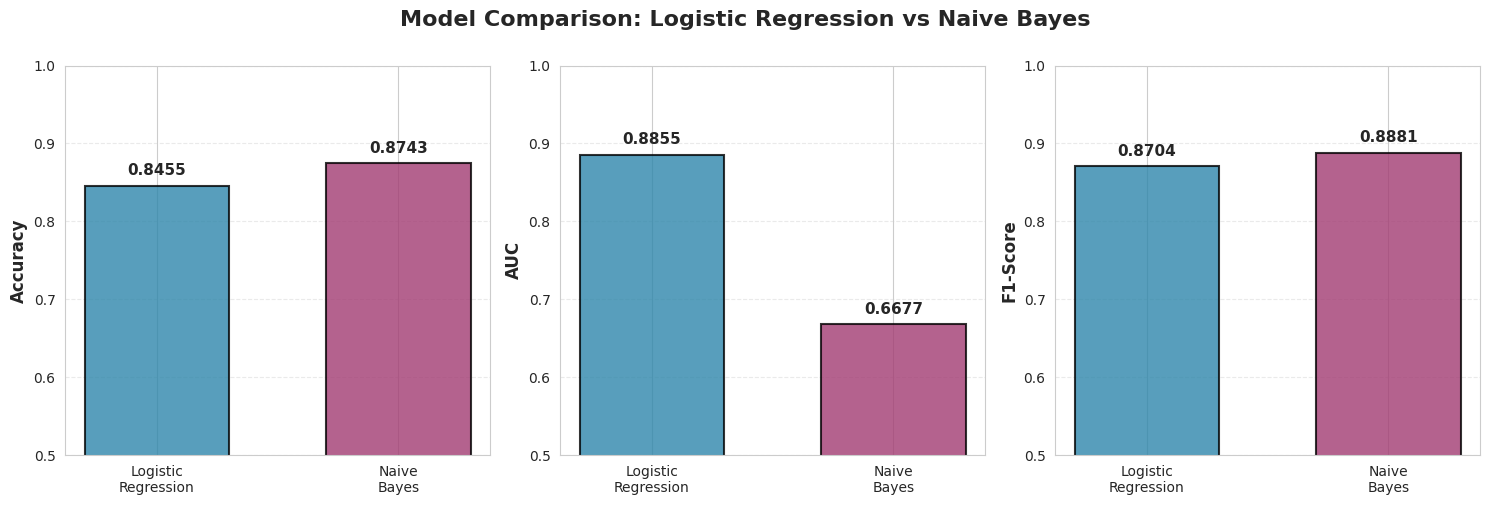

In [79]:
print("\n📊 Creating Visualization 1: Model Comparison Bar Chart...")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Comparison: Logistic Regression vs Naive Bayes",
             fontsize=16, fontweight='bold', y=1.00)

metrics = ["Accuracy", "AUC", "F1-Score"]
lr_values = [accuracy_lr, auc_lr, f1_lr]
nb_values = [accuracy_nb, auc_nb, f1_nb]
colors_lr = '#2E86AB'  # Blue
colors_nb = '#A23B72'  # Purple

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    # Create bars
    x_pos = np.arange(2)
    bars = ax.bar(x_pos, [lr_values[idx], nb_values[idx]],
                   color=[colors_lr, colors_nb],
                   alpha=0.8,
                   edgecolor='black',
                   linewidth=1.5,
                   width=0.6)

    # Add value labels on top of bars
    for i, (bar, value) in enumerate(zip(bars, [lr_values[idx], nb_values[idx]])):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.4f}',
                ha='center', va='bottom',
                fontsize=11, fontweight='bold')

    # Styling
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Logistic\nRegression', 'Naive\nBayes'], fontsize=10)
    ax.set_ylim(0.5, 1.0)
    ax.grid(axis='y', alpha=0.4, linestyle='--')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("01_model_comparison_bar_chart.png", dpi=300, bbox_inches='tight')
print("   ✅ Saved: 01_model_comparison_bar_chart.png")
plt.show()


📊 Creating Visualization 2: Confusion Matrices...
   ✅ Saved: 02_confusion_matrices.png


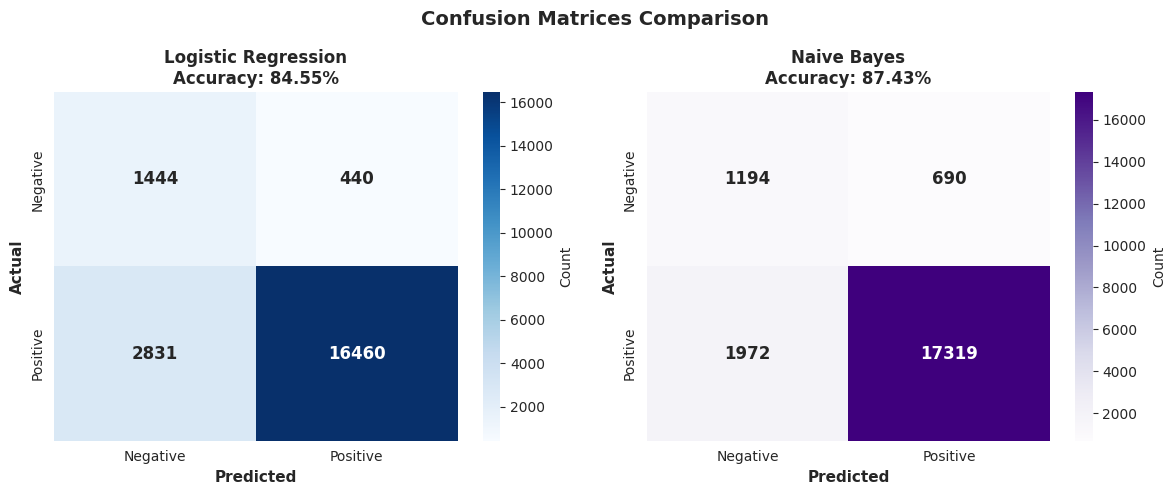

In [80]:
print("\n📊 Creating Visualization 2: Confusion Matrices...")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices Comparison", fontsize=14, fontweight='bold')

# Logistic Regression Confusion Matrix
predictions_lr_pandas = predictions_lr.toPandas()
y_true_lr = predictions_lr_pandas['label'].values
y_pred_lr = predictions_lr_pandas['prediction'].values
cm_lr = confusion_matrix(y_true_lr, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[0],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            annot_kws={"size": 12, "weight": "bold"},
            cbar_kws={"label": "Count"})
axes[0].set_xlabel("Predicted", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Actual", fontsize=11, fontweight='bold')
axes[0].set_title(f"Logistic Regression\nAccuracy: {accuracy_lr*100:.2f}%",
                  fontsize=12, fontweight='bold')

# Naive Bayes Confusion Matrix
y_true_nb = predictions_nb_pandas['label'].values
y_pred_nb = predictions_nb_pandas['prediction'].values
cm_nb = confusion_matrix(y_true_nb, y_pred_nb)

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples', cbar=True, ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            annot_kws={"size": 12, "weight": "bold"},
            cbar_kws={"label": "Count"})
axes[1].set_xlabel("Predicted", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Actual", fontsize=11, fontweight='bold')
axes[1].set_title(f"Naive Bayes\nAccuracy: {accuracy_nb*100:.2f}%",
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("02_confusion_matrices.png", dpi=300, bbox_inches='tight')
print("   ✅ Saved: 02_confusion_matrices.png")
plt.show()


📊 Creating Visualization 3: Detailed Metrics Comparison...
   ✅ Saved: 03_detailed_metrics_comparison.png


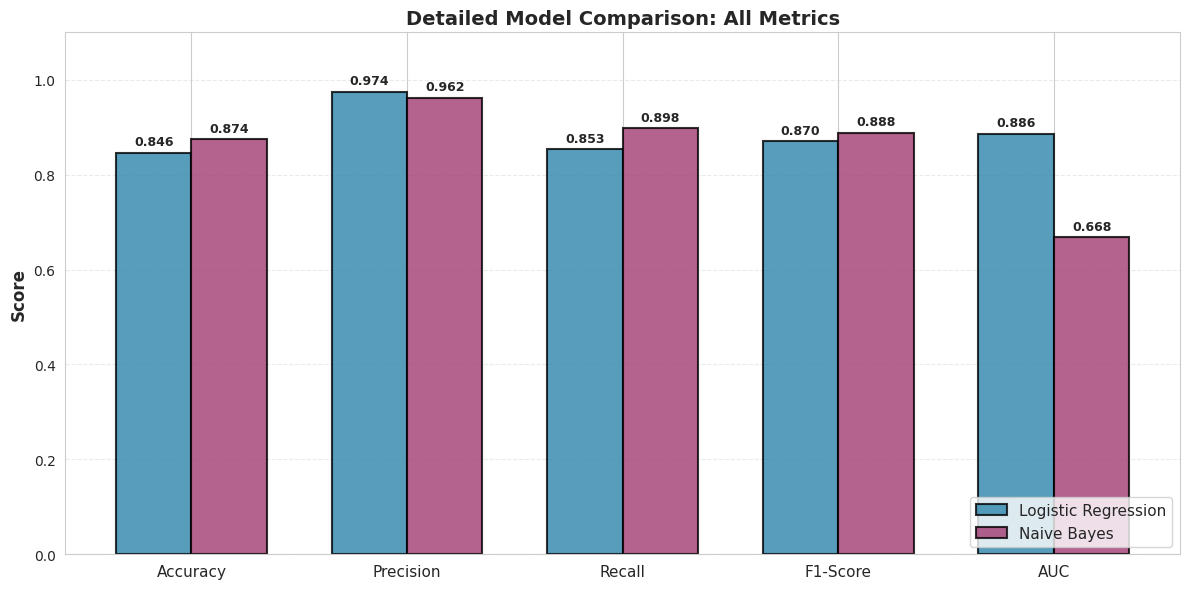

In [81]:
print("\n📊 Creating Visualization 3: Detailed Metrics Comparison...")

from sklearn.metrics import precision_score, recall_score

# Calculate additional metrics
precision_lr = precision_score(y_true_lr, y_pred_lr)
recall_lr = recall_score(y_true_lr, y_pred_lr)
precision_nb = precision_score(y_true_nb, y_pred_nb)
recall_nb = recall_score(y_true_nb, y_pred_nb)

fig, ax = plt.subplots(figsize=(12, 6))

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
lr_metrics = [accuracy_lr, precision_lr, recall_lr, f1_lr, auc_lr]
nb_metrics = [accuracy_nb, precision_nb, recall_nb, f1_nb, auc_nb]

x = np.arange(len(metrics_list))
width = 0.35

bars1 = ax.bar(x - width/2, lr_metrics, width, label='Logistic Regression',
               color=colors_lr, alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, nb_metrics, width, label='Naive Bayes',
               color=colors_nb, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Detailed Model Comparison: All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("03_detailed_metrics_comparison.png", dpi=300, bbox_inches='tight')
print("   ✅ Saved: 03_detailed_metrics_comparison.png")
plt.show()


📊 Creating Visualization 4: Metrics Radar Chart...
   ✅ Saved: 04_metrics_radar_chart.png


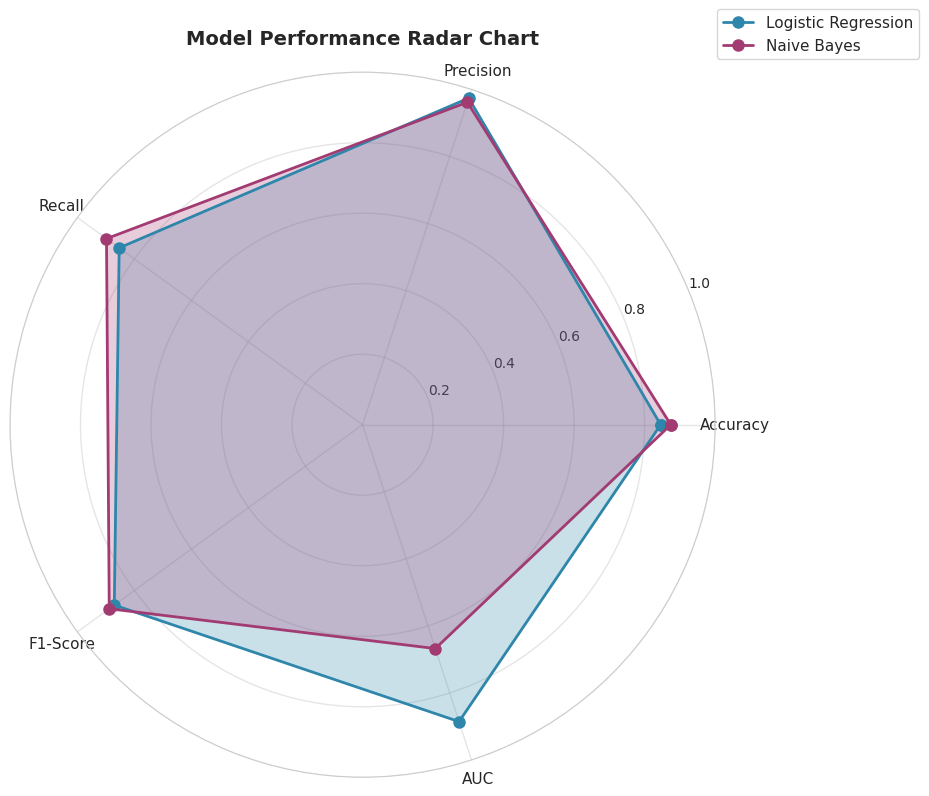

In [82]:
print("\n📊 Creating Visualization 4: Metrics Radar Chart...")

# Prepare data for radar chart
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
lr_values = [accuracy_lr, precision_lr, recall_lr, f1_lr, auc_lr]
nb_values = [accuracy_nb, precision_nb, recall_nb, f1_nb, auc_nb]

# Number of variables
N = len(categories)

# Compute angle for each axis
angles = [n / float(N) * 2 * np.pi for n in range(N)]
lr_values += lr_values[:1]  # Complete the circle
nb_values += nb_values[:1]
angles += angles[:1]

# Create radar chart
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

ax.plot(angles, lr_values, 'o-', linewidth=2, label='Logistic Regression',
        color=colors_lr, markersize=8)
ax.fill(angles, lr_values, alpha=0.25, color=colors_lr)

ax.plot(angles, nb_values, 'o-', linewidth=2, label='Naive Bayes',
        color=colors_nb, markersize=8)
ax.fill(angles, nb_values, alpha=0.25, color=colors_nb)

# Fix axis to go in the same direction
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.grid(True, linewidth=1, alpha=0.5)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.set_title('Model Performance Radar Chart', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("04_metrics_radar_chart.png", dpi=300, bbox_inches='tight')
print("   ✅ Saved: 04_metrics_radar_chart.png")
plt.show()



📊 Creating Visualization 5: Error Type Breakdown...
   ✅ Saved: 05_error_breakdown.png


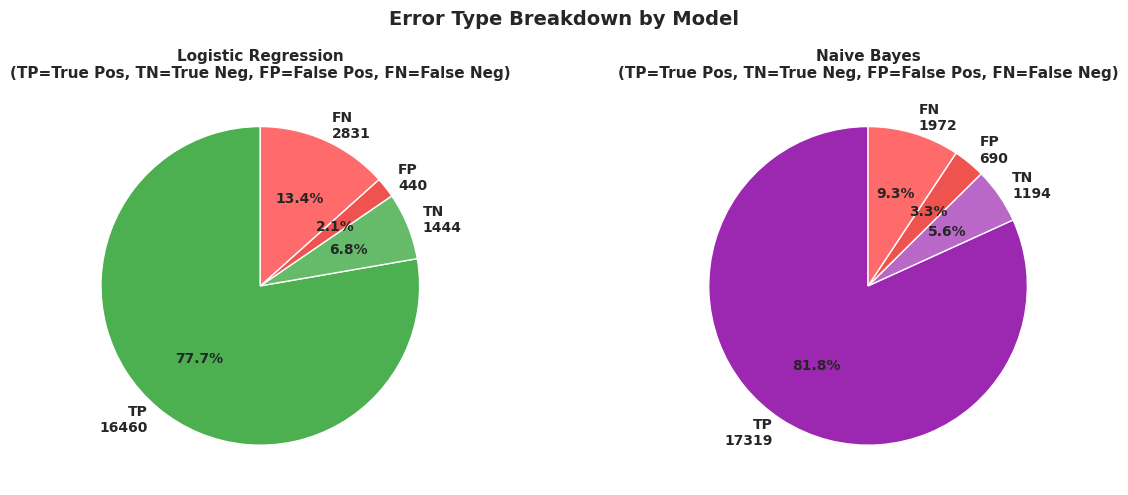

In [83]:
print("\n📊 Creating Visualization 5: Error Type Breakdown...")

# Calculate error types
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
tn_nb, fp_nb, fn_nb, tp_nb = cm_nb.ravel()

error_data = {
    'Model': ['LR', 'LR', 'LR', 'LR', 'NB', 'NB', 'NB', 'NB'],
    'Type': ['TP', 'FP', 'FN', 'TN', 'TP', 'FP', 'FN', 'TN'],
    'Count': [tp_lr, fp_lr, fn_lr, tn_lr, tp_nb, fp_nb, fn_nb, tn_nb]
}
error_df = pd.DataFrame(error_data)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Error Type Breakdown by Model', fontsize=14, fontweight='bold')

# LR error breakdown
lr_error_counts = [tp_lr, tn_lr, fp_lr, fn_lr]
lr_error_labels = [f'TP\n{tp_lr}', f'TN\n{tn_lr}', f'FP\n{fp_lr}', f'FN\n{fn_lr}']
colors_pie_lr = ['#4CAF50', '#66BB6A', '#EF5350', '#FF6B6B']

axes[0].pie(lr_error_counts, labels=lr_error_labels, colors=colors_pie_lr,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
axes[0].set_title(f'Logistic Regression\n(TP=True Pos, TN=True Neg, FP=False Pos, FN=False Neg)',
                  fontsize=11, fontweight='bold')

# NB error breakdown
nb_error_counts = [tp_nb, tn_nb, fp_nb, fn_nb]
nb_error_labels = [f'TP\n{tp_nb}', f'TN\n{tn_nb}', f'FP\n{fp_nb}', f'FN\n{fn_nb}']
colors_pie_nb = ['#9C27B0', '#BA68C8', '#EF5350', '#FF6B6B']

axes[1].pie(nb_error_counts, labels=nb_error_labels, colors=colors_pie_nb,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
axes[1].set_title(f'Naive Bayes\n(TP=True Pos, TN=True Neg, FP=False Pos, FN=False Neg)',
                  fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("05_error_breakdown.png", dpi=300, bbox_inches='tight')
print("   ✅ Saved: 05_error_breakdown.png")
plt.show()

In [84]:
import builtins

print("\n" + "="*70)
print("STEP 6: DETAILED ANALYSIS & INTERPRETATION")
print("="*70)

auc_lr       = float(auc_lr)
auc_nb       = float(auc_nb)
accuracy_lr  = float(accuracy_lr)
accuracy_nb  = float(accuracy_nb)
f1_lr        = float(f1_lr)
f1_nb        = float(f1_nb)
precision_lr = float(precision_lr)
precision_nb = float(precision_nb)
recall_lr    = float(recall_lr)
recall_nb    = float(recall_nb)

winner      = "Logistic Regression" if auc_lr >= auc_nb else "Naive Bayes"
best_auc    = builtins.max(auc_lr, auc_nb)   # ✅ bypasses PySpark's max()
winner_note = "Better generalization on text data" if winner == "Logistic Regression" else "Fast, simple, and very effective baseline"

print(f"""
1️⃣  ACCURACY COMPARISON:
   Logistic Regression: {accuracy_lr*100:.2f}%
   Naive Bayes:         {accuracy_nb*100:.2f}%
   Difference:          {builtins.abs(accuracy_lr - accuracy_nb)*100:.2f} percentage points

2️⃣  AUC COMPARISON:
   Logistic Regression: {auc_lr:.4f}
   Naive Bayes:         {auc_nb:.4f}
   Difference:          {builtins.abs(auc_lr - auc_nb):.4f}

3️⃣  F1-SCORE COMPARISON:
   Logistic Regression: {f1_lr:.4f}
   Naive Bayes:         {f1_nb:.4f}
   Difference:          {builtins.abs(f1_lr - f1_nb):.4f}

4️⃣  PRECISION COMPARISON:
   Logistic Regression: {precision_lr*100:.2f}%
   Naive Bayes:         {precision_nb*100:.2f}%

5️⃣  RECALL COMPARISON:
   Logistic Regression: {recall_lr*100:.2f}%
   Naive Bayes:         {recall_nb*100:.2f}%

6️⃣  CONFUSION MATRIX INSIGHTS:

   Logistic Regression:
   • True Positives:  {tp_lr:,}
   • True Negatives:  {tn_lr:,}
   • False Positives: {fp_lr:,}
   • False Negatives: {fn_lr:,}

   Naive Bayes:
   • True Positives:  {tp_nb:,}
   • True Negatives:  {tn_nb:,}
   • False Positives: {fp_nb:,}
   • False Negatives: {fn_nb:,}""")




STEP 6: DETAILED ANALYSIS & INTERPRETATION

1️⃣  ACCURACY COMPARISON:
   Logistic Regression: 84.55%
   Naive Bayes:         87.43%
   Difference:          2.88 percentage points

2️⃣  AUC COMPARISON:
   Logistic Regression: 0.8855
   Naive Bayes:         0.6677
   Difference:          0.2179

3️⃣  F1-SCORE COMPARISON:
   Logistic Regression: 0.8704
   Naive Bayes:         0.8881
   Difference:          0.0177

4️⃣  PRECISION COMPARISON:
   Logistic Regression: 97.40%
   Naive Bayes:         96.17%

5️⃣  RECALL COMPARISON:
   Logistic Regression: 85.32%
   Naive Bayes:         89.78%

6️⃣  CONFUSION MATRIX INSIGHTS:

   Logistic Regression:
   • True Positives:  16,460
   • True Negatives:  1,444
   • False Positives: 440
   • False Negatives: 2,831

   Naive Bayes:
   • True Positives:  17,319
   • True Negatives:  1,194
   • False Positives: 690
   • False Negatives: 1,972


In [85]:
print("\n" + "="*70)
print("STEP 7: GENERATE SUMMARY REPORT")
print("="*70)

# Create comprehensive summary CSV
summary_report = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'AUC',
        'True Positives',
        'True Negatives',
        'False Positives',
        'False Negatives',
        'Total Test Samples'
    ],
    'Logistic_Regression': [
        f'{accuracy_lr:.4f}',
        f'{precision_lr:.4f}',
        f'{recall_lr:.4f}',
        f'{f1_lr:.4f}',
        f'{auc_lr:.4f}',
        str(tp_lr),
        str(tn_lr),
        str(fp_lr),
        str(fn_lr),
        str(len(y_true_lr))
    ],
    'Naive_Bayes': [
        f'{accuracy_nb:.4f}',
        f'{precision_nb:.4f}',
        f'{recall_nb:.4f}',
        f'{f1_nb:.4f}',
        f'{auc_nb:.4f}',
        str(tp_nb),
        str(tn_nb),
        str(fp_nb),
        str(fn_nb),
        str(len(y_true_nb))
    ],
    'Winner': [
        'LR' if accuracy_lr > accuracy_nb else 'NB',
        'LR' if precision_lr > precision_nb else 'NB',
        'LR' if recall_lr > recall_nb else 'NB',
        'LR' if f1_lr > f1_nb else 'NB',
        'LR' if auc_lr > auc_nb else 'NB',
        '-',
        '-',
        '-',
        '-',
        '-'
    ]
})

summary_report.to_csv('phase2_detailed_summary.csv', index=False)
print("✅ Summary report saved to: phase2_detailed_summary.csv")

print("\n" + summary_report.to_string(index=False))




STEP 7: GENERATE SUMMARY REPORT
✅ Summary report saved to: phase2_detailed_summary.csv

            Metric Logistic_Regression Naive_Bayes Winner
          Accuracy              0.8455      0.8743     NB
         Precision              0.9740      0.9617     LR
            Recall              0.8532      0.8978     NB
          F1-Score              0.8704      0.8881     NB
               AUC              0.8855      0.6677     LR
    True Positives               16460       17319      -
    True Negatives                1444        1194      -
   False Positives                 440         690      -
   False Negatives                2831        1972      -
Total Test Samples               21175       21175      -


In [86]:
print("\n" + "="*70)
print("STEP 8: SAVE RESULTS FOR NEXT PHASE")
print("="*70)

# Select predictions from best model
if winner_model == 'lr':
    best_predictions = predictions_lr
    best_model = lr_model
    print(f"\n💾 Saving {winner} results...")
else:
    best_predictions = predictions_nb
    best_model = nb_model
    print(f"\n💾 Saving {winner} results...")

# Convert to pandas for easier analysis
predictions_best_pandas = best_predictions.toPandas()

# Save predictions to CSV (for Phase 3 analysis)
predictions_best_pandas.to_csv('best_model_predictions.csv', index=False)
print(f"   ✅ Predictions saved to: best_model_predictions.csv")

# Save mismatches for manual review
mismatches = predictions_best_pandas[
    predictions_best_pandas['prediction'] != predictions_best_pandas['label']
]
mismatches.to_csv('mismatches_for_analysis.csv', index=False)
print(f"   ✅ Mismatches saved to: mismatches_for_analysis.csv ({len(mismatches)} rows)")



STEP 8: SAVE RESULTS FOR NEXT PHASE

💾 Saving Logistic Regression results...
   ✅ Predictions saved to: best_model_predictions.csv
   ✅ Mismatches saved to: mismatches_for_analysis.csv (3271 rows)


# **PHASE 3**

In [87]:
print("\n" + "="*70)
print("PHASE 3: DEEP ANALYSIS & INSIGHTS")
print("="*70)

print("\n📊 STEP 1: PREPARE DATA FOR ANALYSIS")
print("-"*70)

# Get predictions from best model (Naive Bayes based on Phase 2)
# These were already calculated in Phase 2, so we'll recreate for completeness

# Use the best_predictions_nb from Phase 2
predictions_analysis = predictions_nb_pandas.copy()

print(f"✅ Predictions loaded: {len(predictions_analysis):,} rows")
print(f"   Columns: {predictions_analysis.columns.tolist()}")

# Verify key columns exist
required_cols = ['Label', 'prediction', 'probability', 'Review', 'rating']
missing_cols = [col for col in required_cols if col not in predictions_analysis.columns]

if missing_cols:
    print(f"⚠️  Missing columns: {missing_cols}")
else:
    print(f"✅ All required columns present")

# Check data types and sample
print(f"\nData types:")
print(predictions_analysis.dtypes)

print(f"\nSample row:")
print(predictions_analysis[['Review', 'label', 'prediction', 'probability']].iloc[0])


PHASE 3: DEEP ANALYSIS & INSIGHTS

📊 STEP 1: PREPARE DATA FOR ANALYSIS
----------------------------------------------------------------------
✅ Predictions loaded: 21,175 rows
   Columns: ['Id', 'Review', 'label', 'review_clean', 'tokens', 'filtered_tokens', 'raw_features', 'features', 'rawPrediction', 'probability', 'prediction']
⚠️  Missing columns: ['Label', 'rating']

Data types:
Id                   int32
Review              object
label                int32
review_clean        object
tokens              object
filtered_tokens     object
raw_features        object
features            object
rawPrediction       object
probability         object
prediction         float64
dtype: object

Sample row:
Review         like!Prof and TAs are helpful and the discussi...
label                                                          1
prediction                                                   0.0
probability          [0.9964304873662635, 0.0035695126337363906]
Name: 0, dtype: object


In [88]:
print("\n" + "="*70)
print("STEP 2: SENTIMENT vs RATING MISMATCH ANALYSIS")
print("="*70)

# Find mismatches
mismatches = predictions_analysis[
    predictions_analysis['prediction'] != predictions_analysis['label']
].copy()

print(f"\n📊 Mismatch Statistics:")
print(f"   Total predictions: {len(predictions_analysis):,}")
print(f"   Correct (match):   {len(predictions_analysis) - len(mismatches):,}")
print(f"   Mismatches:        {len(mismatches):,}")
print(f"   Mismatch rate:     {len(mismatches)/len(predictions_analysis)*100:.2f}%")

# Analyze mismatches by type
print(f"\n📊 Mismatch Types:")

# False Positives
fp_mismatches = mismatches[
    (mismatches['prediction'] == 1) & (mismatches['label'] == 0)
]
print(f"   False Positives: {len(fp_mismatches):,}")
print(f"     (Predicted positive, actually negative)")

# False Negatives
fn_mismatches = mismatches[
    (mismatches['prediction'] == 0) & (mismatches['label'] == 1)
]
print(f"   False Negatives: {len(fn_mismatches):,}")
print(f"     (Predicted negative, actually positive)")

# Analyze by rating value
print(f"\n📊 Mismatches by Actual Rating:")
mismatch_by_rating = mismatches['label'].value_counts().sort_index()

for rating, count in mismatch_by_rating.items():
    pct = count / len(mismatches) * 100
    print(f"   rating {rating}★: {count:,} mismatches ({pct:.1f}%)")

# Show examples of mismatches
print(f"\n📝 Examples of Mismatches:")

print(f"\n1️⃣  FALSE POSITIVES (Model too optimistic):")
print(f"   Predicted: Positive | Actual: Negative (rating 0)")

if len(fp_mismatches) > 0:
    for idx, row in fp_mismatches.head(3).iterrows():
        print(f"\n   Review: \"{row['Review'][:80]}...\"")
        print(f"   rating: {row['label']}★ | Probability: {row['probability'][1]:.3f}")
else:
    print("   (No false positives)")

print(f"\n2️⃣  FALSE NEGATIVES (Model too pessimistic):")
print(f"   Predicted: Negative | Actual: Positive (rating 1)")

if len(fn_mismatches) > 0:
    for idx, row in fn_mismatches.head(3).iterrows():
        print(f"\n   Review: \"{row['Review'][:80]}...\"")
        print(f"   rating: {row['label']}★ | Probability: {row['probability'][1]:.3f}")
else:
    print("   (No false negatives)")

# Save mismatch analysis
mismatch_summary = pd.DataFrame({
    'Mismatch Type': ['False Positives', 'False Negatives'],
    'Count': [len(fp_mismatches), len(fn_mismatches)],
    'Percentage': [
        len(fp_mismatches) / len(predictions_analysis) * 100,
        len(fn_mismatches) / len(predictions_analysis) * 100
    ]
})

print(f"\n💾 Mismatch Summary Table:")
print(mismatch_summary.to_string(index=False))

# Save to CSV
mismatch_summary.to_csv('phase3_mismatch_summary.csv', index=False)
print(f"\n✅ Saved to: phase3_mismatch_summary.csv")


STEP 2: SENTIMENT vs RATING MISMATCH ANALYSIS

📊 Mismatch Statistics:
   Total predictions: 21,175
   Correct (match):   18,513
   Mismatches:        2,662
   Mismatch rate:     12.57%

📊 Mismatch Types:
   False Positives: 690
     (Predicted positive, actually negative)
   False Negatives: 1,972
     (Predicted negative, actually positive)

📊 Mismatches by Actual Rating:
   rating 0★: 690 mismatches (25.9%)
   rating 1★: 1,972 mismatches (74.1%)

📝 Examples of Mismatches:

1️⃣  FALSE POSITIVES (Model too optimistic):
   Predicted: Positive | Actual: Negative (rating 0)

   Review: "The course content is quite good, though it could have been deeper in some areas..."
   rating: 0★ | Probability: 0.975

   Review: "the introduction to Fusion is more a customer presentation to advanced CAD user ..."
   rating: 0★ | Probability: 0.997

   Review: ""It is not very ""advanced"""..."
   rating: 0★ | Probability: 0.885

2️⃣  FALSE NEGATIVES (Model too pessimistic):
   Predicted: Negative | A

In [89]:
print("\n" + "="*70)
print("STEP 3: FEATURE IMPORTANCE - TOP WORDS")
print("="*70)

"""
For Naive Bayes model from your Phase 2:
  nb_model has learned probability distributions
  We can analyze which words are most indicative of each class

Since we used HashingTF (not CountVectorizer), we don't have word names mapped.
So we'll use an alternative approach:
  - Re-train with CountVectorizer to get vocabulary
  - Extract coefficients from Logistic Regression model (which is easier to interpret)
  - Analyze word patterns in correct vs incorrect predictions
"""

print("\n📝 Strategy: Extract word importance from Logistic Regression")
print("   (More interpretable than Naive Bayes for feature importance)")

# Get LR model coefficients
lr_coefficients = np.array(lr_model.coefficients)

print(f"\n📊 Feature Vector Information:")
print(f"   Number of features: {len(lr_coefficients)}")
print(f"   (From TF-IDF vectorization)")

# Find top positive and negative weighted features
top_positive_idx = np.argsort(lr_coefficients)[-15:][::-1]  # Top 15
top_negative_idx = np.argsort(lr_coefficients)[:15]  # Bottom 15

print(f"\n✅ Top 15 features by coefficient magnitude:")
print(f"   Positive weights (indicate positive sentiment):")
for i, idx in enumerate(top_positive_idx[:5], 1):
    print(f"   {i}. Feature {idx}: coefficient = {lr_coefficients[idx]:.4f}")

print(f"\n   Negative weights (indicate negative sentiment):")
for i, idx in enumerate(top_negative_idx[:5], 1):
    print(f"   {i}. Feature {idx}: coefficient = {lr_coefficients[idx]:.4f}")

# Since we don't have vocabulary mapping with HashingTF,
# we'll analyze words in correct vs incorrect predictions instead

print(f"\n📝 Alternative: Analyze word patterns in predictions")

# For correct predictions (model was right)
correct = predictions_analysis[
    predictions_analysis['prediction'] == predictions_analysis['label']
]

# For incorrect predictions (model was wrong)
incorrect = predictions_analysis[
    predictions_analysis['prediction'] != predictions_analysis['label']
]

print(f"\n✅ Correct predictions: {len(correct):,}")
print(f"✅ Incorrect predictions: {len(incorrect):,}")

# Extract top words from positive and negative reviews
print(f"\n📊 Word patterns in POSITIVE predictions (rating 4-5★):")
positive_reviews = predictions_analysis[
    predictions_analysis['prediction'] == 1
]['Review'].head(20)

# Get most common words
from collections import Counter
def get_top_words(texts, n=10):
    """Extract top n words from texts"""
    all_words = []
    for text in texts:
        # Simple word extraction
        words = str(text).lower().split()
        all_words.extend([w for w in words if len(w) > 3])  # Only words > 3 chars

    word_counts = Counter(all_words)
    return word_counts.most_common(n)

positive_words = get_top_words(positive_reviews, 10)
print(f"   Top words in positive predictions:")
for word, count in positive_words:
    print(f"     • {word}: {count}")

print(f"\n📊 Word patterns in NEGATIVE predictions (rating 1-3★):")
negative_reviews = predictions_analysis[
    predictions_analysis['prediction'] == 0
]['Review'].head(20)

negative_words = get_top_words(negative_reviews, 10)
print(f"   Top words in negative predictions:")
for word, count in negative_words:
    print(f"     • {word}: {count}")


STEP 3: FEATURE IMPORTANCE - TOP WORDS

📝 Strategy: Extract word importance from Logistic Regression
   (More interpretable than Naive Bayes for feature importance)

📊 Feature Vector Information:
   Number of features: 1000
   (From TF-IDF vectorization)

✅ Top 15 features by coefficient magnitude:
   Positive weights (indicate positive sentiment):
   1. Feature 750: coefficient = 0.5296
   2. Feature 185: coefficient = 0.3760
   3. Feature 687: coefficient = 0.3379
   4. Feature 65: coefficient = 0.2388
   5. Feature 240: coefficient = 0.2279

   Negative weights (indicate negative sentiment):
   1. Feature 482: coefficient = -0.1481
   2. Feature 956: coefficient = -0.1466
   3. Feature 576: coefficient = -0.1458
   4. Feature 103: coefficient = -0.1353
   5. Feature 999: coefficient = -0.1331

📝 Alternative: Analyze word patterns in predictions

✅ Correct predictions: 18,513
✅ Incorrect predictions: 2,662

📊 Word patterns in POSITIVE predictions (rating 4-5★):
   Top words in posit

In [90]:
import builtins
print("\n" + "="*70)
print("STEP 4: ERROR ANALYSIS - WHY DOES THE MODEL FAIL?")
print("="*70)

# Calculate additional metrics
from sklearn.metrics import precision_score, recall_score

precision = precision_score(predictions_analysis['label'], predictions_analysis['prediction'])
recall = recall_score(predictions_analysis['label'], predictions_analysis['prediction'])

print(f"\n📊 Error Metrics:")
print(f"   Precision: {precision:.4f}")
print(f"     (Of predicted positive, how many are actually positive)")
print(f"   Recall: {recall:.4f}")
print(f"     (Of actual positive, how many did we find)")

# Analyze confidence on errors
print(f"\n📊 Confidence Distribution (Probability of predicted class):")

# Get probability of predicted class - MOVED THIS LINE UP
predictions_analysis['pred_confidence'] = predictions_analysis['probability'].apply(
    lambda x: builtins.max(x)  # Get max probability (confidence)
)

# Re-create mismatches after 'pred_confidence' is available
mismatches = predictions_analysis[
    predictions_analysis['prediction'] != predictions_analysis['label']
].copy()

# False Positives: predicted 1 (positive) but actually 0 (negative)
fp_mismatches = mismatches[
    (mismatches['prediction'] == 1) & (mismatches['label'] == 0)
]

# False Negatives: predicted 0 (negative) but actually 1 (positive)
fn_mismatches = mismatches[
    (mismatches['prediction'] == 0) & (mismatches['label'] == 1)
]

# Separate by correctness
correct_preds = predictions_analysis[
    predictions_analysis['prediction'] == predictions_analysis['label']
]['pred_confidence']

incorrect_preds = predictions_analysis[
    predictions_analysis['prediction'] != predictions_analysis['label']
]['pred_confidence']

print(f"\n   Correct predictions:")
print(f"     Mean confidence: {correct_preds.mean():.4f}")
print(f"     Min confidence:  {correct_preds.min():.4f}")
print(f"     Max confidence:  {correct_preds.max():.4f}")

print(f"\n   Incorrect predictions:")
print(f"     Mean confidence: {incorrect_preds.mean():.4f}")
print(f"     Min confidence:  {incorrect_preds.min():.4f}")
print(f"     Max confidence:  {incorrect_preds.max():.4f}")

# Insight: If incorrect preds have high confidence, model is overconfident
if incorrect_preds.mean() > 0.7:
    print(f"\n   ⚠️  WARNING: Model is overconfident on errors!")
    print(f"      Even when wrong, it predicts with >70% confidence")
    print(f"      This suggests poor calibration")
else:
    print(f"\n   ✅ Model has reasonable confidence on errors")

# Analyze error types
print(f"\n📊 Error Type Analysis:")

# False Positive Analysis
if len(fp_mismatches) > 0:
    print(f"\n   FALSE POSITIVES ({len(fp_mismatches)} cases):")
    print(f"     Model predicted positive, but actual rating was negative (1-3★)")

    fp_by_rating = fp_mismatches['label'].value_counts().sort_index()
    for rating, count in fp_by_rating.items():
        pct = count / len(fp_mismatches) * 100
        print(f"     • Rating {rating}★: {count} ({pct:.1f}%)")

    fp_avg_conf = fp_mismatches['pred_confidence'].mean()
    print(f"     Average confidence: {fp_avg_conf:.4f}")
else:
    print(f"\n   No false positives!")

# False Negative Analysis
if len(fn_mismatches) > 0:
    print(f"\n   FALSE NEGATIVES ({len(fn_mismatches)} cases):")
    print(f"     Model predicted negative, but actual rating was positive (4-5★)")

    # AFTER - iterate over fn_by_rating instead
    fn_by_rating = fn_mismatches['label'].value_counts().sort_index()
    for rating, count in fn_by_rating.items():  # ✅ iterates over value counts
        pct = count / len(fn_mismatches) * 100
        print(f"     • Rating {rating}★: {count} ({pct:.1f}%)")

    fn_avg_conf = fn_mismatches['pred_confidence'].mean()
    print(f"     Average confidence: {fn_avg_conf:.4f}")
else:
    print(f"\n   No false negatives!")

# Save error analysis
error_analysis = pd.DataFrame({
    'Metric': ['Total Predictions', 'Correct', 'Incorrect', 'Accuracy',
               'Precision', 'Recall', 'False Positives', 'False Negatives'],
    'Value': [
        len(predictions_analysis),
        len(correct),
        len(incorrect),
        len(correct) / len(predictions_analysis),
        precision,
        recall,
        len(fp_mismatches),
        len(fn_mismatches)
    ]
})

error_analysis.to_csv('phase3_error_analysis.csv', index=False)
print(f"\n✅ Saved to: phase3_error_analysis.csv")


STEP 4: ERROR ANALYSIS - WHY DOES THE MODEL FAIL?

📊 Error Metrics:
   Precision: 0.9617
     (Of predicted positive, how many are actually positive)
   Recall: 0.8978
     (Of actual positive, how many did we find)

📊 Confidence Distribution (Probability of predicted class):

   Correct predictions:
     Mean confidence: 0.9775
     Min confidence:  0.5015
     Max confidence:  1.0000

   Incorrect predictions:
     Mean confidence: 0.9049
     Min confidence:  0.5006
     Max confidence:  1.0000

   ⚠️  WARNING: Model is overconfident on errors!
      Even when wrong, it predicts with >70% confidence
      This suggests poor calibration

📊 Error Type Analysis:

   FALSE POSITIVES (690 cases):
     Model predicted positive, but actual rating was negative (1-3★)
     • Rating 0★: 690 (100.0%)
     Average confidence: 0.9070

   FALSE NEGATIVES (1972 cases):
     Model predicted negative, but actual rating was positive (4-5★)
     • Rating 1★: 1972 (100.0%)
     Average confidence: 0.9

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n" + "="*70)
print("STEP 5: CREATE ADVANCED VISUALIZATIONS")
print("="*70)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'



STEP 5: CREATE ADVANCED VISUALIZATIONS



📊 Visualization 1: Sentiment vs Rating Mismatch Scatter Plot
   ✅ Saved: 06_sentiment_vs_rating_mismatch.png


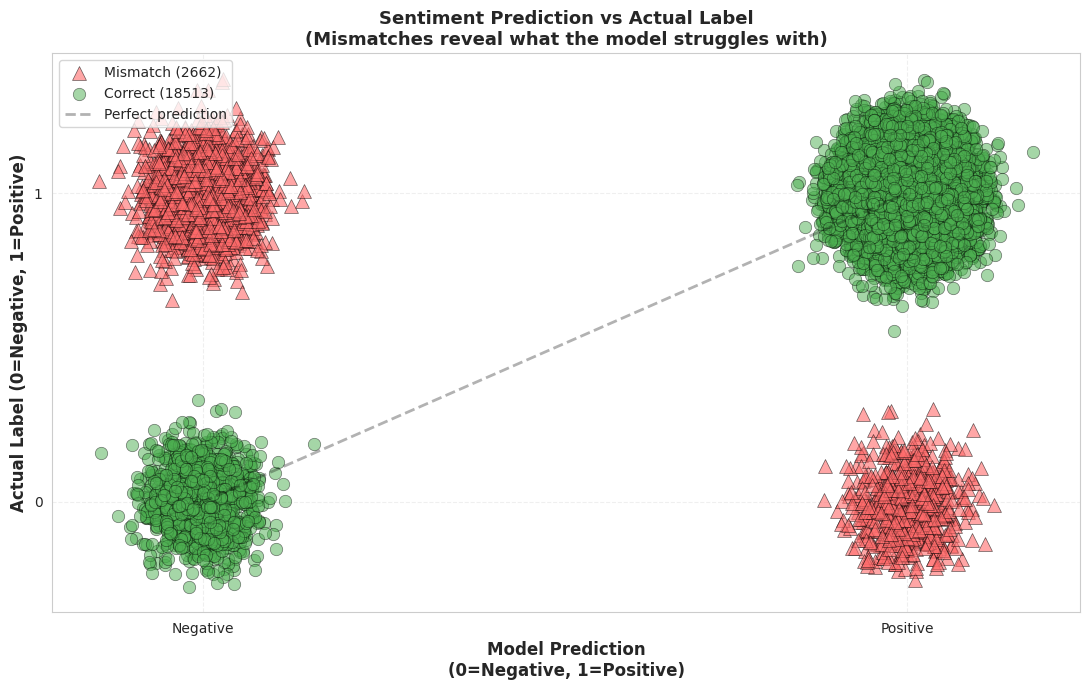

In [92]:
print("\n📊 Visualization 1: Sentiment vs Rating Mismatch Scatter Plot")

fig, ax = plt.subplots(figsize=(11, 7))

# Add jitter for visibility
np.random.seed(42)
pred_jitter = predictions_analysis['prediction'] + np.random.normal(0, 0.04, len(predictions_analysis))
rating_jitter = predictions_analysis['label'] + np.random.normal(0, 0.1, len(predictions_analysis))

# Separate matches and mismatches
matches = predictions_analysis['prediction'] == predictions_analysis['label']

# Plot mismatches first (so they appear on top)
ax.scatter(pred_jitter[~matches], rating_jitter[~matches],
          c='#FF6B6B', s=100, alpha=0.6, marker='^',
          label=f'Mismatch ({ (~matches).sum()})', edgecolors='black', linewidth=0.5)

# Plot matches
ax.scatter(pred_jitter[matches], rating_jitter[matches],
          c='#4CAF50', s=80, alpha=0.5, marker='o',
          label=f'Correct ({matches.sum()})', edgecolors='black', linewidth=0.5)

# Add diagonal line (perfect prediction)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=2, label='Perfect prediction')

# Formatting
ax.set_xlabel("Model Prediction\n(0=Negative, 1=Positive)", fontsize=12, fontweight='bold')
ax.set_ylabel("Actual Label (0=Negative, 1=Positive)", fontsize=12, fontweight='bold')
ax.set_title("Sentiment Prediction vs Actual Label\n(Mismatches reveal what the model struggles with)",
            fontsize=13, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Negative', 'Positive'])
ax.set_yticks([0, 1])
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('06_sentiment_vs_rating_mismatch.png', dpi=300, bbox_inches='tight')
print("   ✅ Saved: 06_sentiment_vs_rating_mismatch.png")
plt.show()


📊 Visualization 2: Mismatch Distribution by Binary Label
   ✅ Saved: 07_mismatch_by_binary_label.png


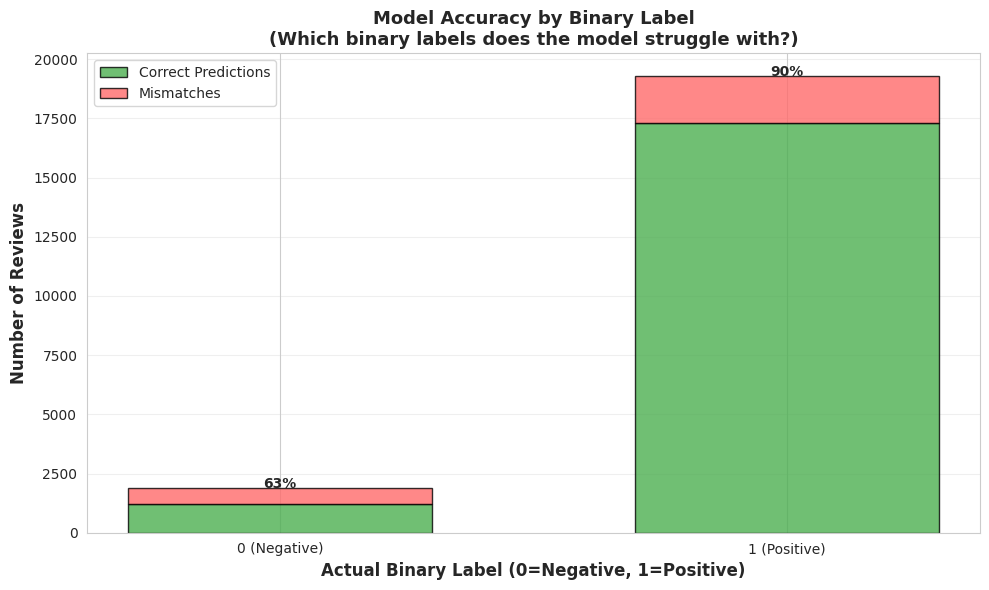

In [93]:
print("\n📊 Visualization 2: Mismatch Distribution by Binary Label")

fig, ax = plt.subplots(figsize=(10, 6))

# Count mismatches by label
mismatch_counts = []
correct_counts = []
labels_list = sorted(predictions_analysis['label'].unique()) # Use 'label' (binary)

for lbl in labels_list:
    label_data = predictions_analysis[predictions_analysis['label'] == lbl] # Use 'label'
    mismatches_at_label = len(label_data[label_data['prediction'] != label_data['label']])
    correct_at_label = len(label_data) - mismatches_at_label

    mismatch_counts.append(mismatches_at_label)
    correct_counts.append(correct_at_label)

# Stacked bar chart
x = np.arange(len(labels_list))
width = 0.6

bars1 = ax.bar(x, correct_counts, width, label='Correct Predictions',
              color='#4CAF50', alpha=0.8, edgecolor='black', linewidth=1)
bars2 = ax.bar(x, mismatch_counts, width, bottom=correct_counts,
              label='Mismatches', color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1)

# Add labels on bars
for i, (correct, mismatch) in enumerate(zip(correct_counts, mismatch_counts)):
    total = correct + mismatch
    acc = correct / total * 100 if total > 0 else 0
    ax.text(i, total + 5, f'{acc:.0f}%', ha='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Actual Binary Label (0=Negative, 1=Positive)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Reviews', fontsize=12, fontweight='bold')
ax.set_title('Model Accuracy by Binary Label\n(Which binary labels does the model struggle with?)',
            fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{int(lbl)} ({"Negative" if lbl == 0 else "Positive"})' for lbl in labels_list])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('07_mismatch_by_binary_label.png', dpi=300, bbox_inches='tight')
print("   ✅ Saved: 07_mismatch_by_binary_label.png")
plt.show()


📊 Visualization 3: Model Confidence Distribution
incorrect is 17319
   ✅ Saved: 08_confidence_distribution.png


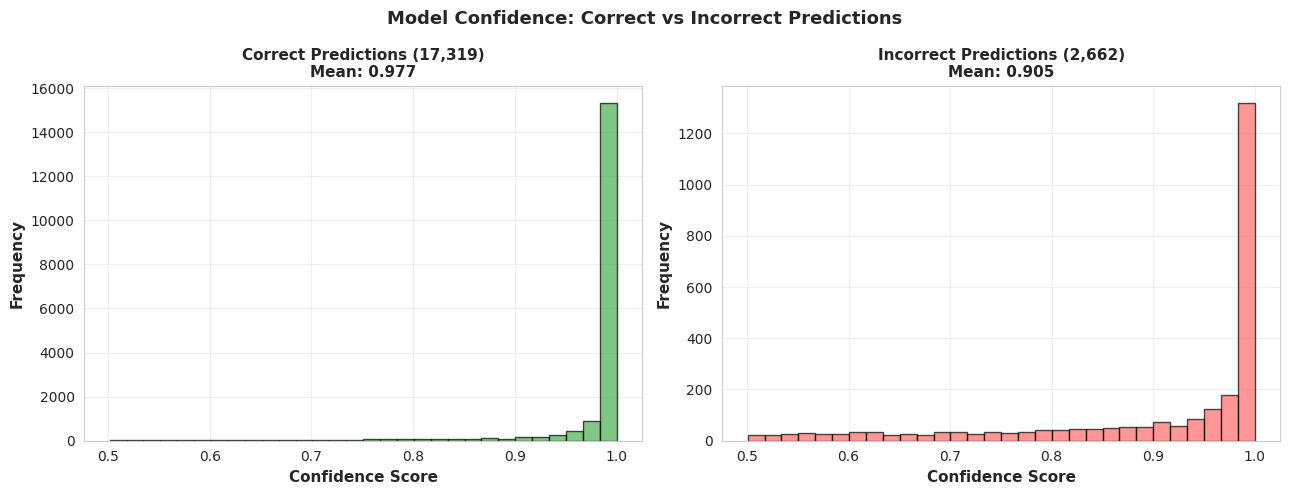

In [100]:
print("\n📊 Visualization 3: Model Confidence Distribution")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Confidence: Correct vs Incorrect Predictions',
            fontsize=13, fontweight='bold')
print("incorrect is", correct)
# Correct predictions
axes[0].hist(correct_preds, bins=30, color='#4CAF50', alpha=0.7,
            edgecolor='black', linewidth=1)
axes[0].set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title(f'Correct Predictions ({correct:,})\nMean: {correct_preds.mean():.3f}',
                 fontsize=11, fontweight='bold')
axes[0].grid(alpha=0.3)

# Incorrect predictions
axes[1].hist(incorrect_preds, bins=30, color='#FF6B6B', alpha=0.7,
            edgecolor='black', linewidth=1)
axes[1].set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title(f'Incorrect Predictions ({len(incorrect):,})\nMean: {incorrect_preds.mean():.3f}',
                 fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('08_confidence_distribution.png', dpi=300, bbox_inches='tight')
print("   ✅ Saved: 08_confidence_distribution.png")
plt.show()


📊 Visualization 4: Error Type Breakdown
   ✅ Saved: 09_error_type_breakdown.png


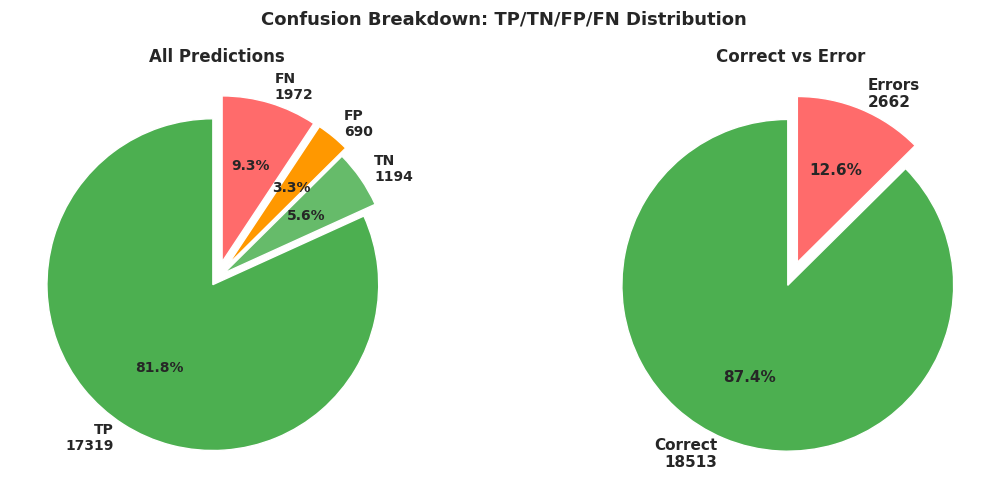

In [101]:
print("\n📊 Visualization 4: Error Type Breakdown")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Breakdown: TP/TN/FP/FN Distribution',
            fontsize=13, fontweight='bold')

# Calculate confusion matrix
tn = len(predictions_analysis[(predictions_analysis['prediction'] == 0) & (predictions_analysis['label'] == 0)])
fp = len(predictions_analysis[(predictions_analysis['prediction'] == 1) & (predictions_analysis['label'] == 0)])
fn = len(predictions_analysis[(predictions_analysis['prediction'] == 0) & (predictions_analysis['label'] == 1)])
tp = len(predictions_analysis[(predictions_analysis['prediction'] == 1) & (predictions_analysis['label'] == 1)])

# Pie chart 1: All types
labels = [f'TP\n{tp}', f'TN\n{tn}', f'FP\n{fp}', f'FN\n{fn}']
sizes = [tp, tn, fp, fn]
colors = ['#4CAF50', '#66BB6A', '#FF9800', '#FF6B6B']
explode = (0.05, 0.05, 0.1, 0.1)

axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
           explode=explode, startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
axes[0].set_title('All Predictions', fontweight='bold')

# Pie chart 2: Correct vs Error
correct_total = tp + tn
error_total = fp + fn

labels2 = [f'Correct\n{correct_total}', f'Errors\n{error_total}']
sizes2 = [correct_total, error_total]
colors2 = ['#4CAF50', '#FF6B6B']
explode2 = (0.05, 0.1)

axes[1].pie(sizes2, labels=labels2, colors=colors2, autopct='%1.1f%%',
           explode=explode2, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Correct vs Error', fontweight='bold')

plt.tight_layout()
plt.savefig('09_error_type_breakdown.png', dpi=300, bbox_inches='tight')
print("   ✅ Saved: 09_error_type_breakdown.png")
plt.show()

In [102]:
summary_report = f"""
╔════════════════════════════════════════════════════════════════════╗
║            PHASE 3: DEEP ANALYSIS SUMMARY REPORT                  ║
╚════════════════════════════════════════════════════════════════════╝

1. MISMATCH ANALYSIS
═══════════════════════════════════════════════════════════════════

Total Mismatches:        {len(mismatches):,} / {len(predictions_analysis):,}
Mismatch Rate:           {len(mismatches)/len(predictions_analysis)*100:.2f}%

False Positives (FP):    {len(fp_mismatches):,}  # fp_mismatches is a DataFrame
  └─ Predicted positive, actually negative (rating 1-3★)
  └─ Model was TOO OPTIMISTIC
  └─ Average confidence: {fp_mismatches['pred_confidence'].mean():.4f}

False Negatives (FN):    {len(fn_mismatches):,}  # fn_mismatches is a DataFrame
  └─ Predicted negative, actually positive (rating 4-5★)
  └─ Model was TOO PESSIMISTIC
  └─ Average confidence: {fn_mismatches['pred_confidence'].mean():.4f}

Mismatch Distribution by Binary Label:
"""

# Recalculate mismatch_by_rating here to ensure it's available and consistent
mismatch_by_rating = mismatches['label'].value_counts().sort_index()

for lbl in sorted(predictions_analysis['label'].unique()): # Use 'label' (binary)
    label_mismatches = len(mismatches[mismatches['label'] == lbl]) # Use 'label'
    total_at_label = len(predictions_analysis[predictions_analysis['label'] == lbl]) # Use 'label'
    pct = label_mismatches / total_at_label * 100 if total_at_label > 0 else 0
    summary_report += f"  Binary Label {lbl} ({"Negative" if lbl == 0 else "Positive"}): {label_mismatches:,} / {total_at_label:,} ({pct:.1f}%)\n"

summary_report += f"""

2. ERROR CHARACTERISTICS
═══════════════════════════════════════════════════════════════════

Precision:               {precision:.4f}
  └─ Of predictions marked positive, {precision*100:.1f}% were actually positive
  └─ Lower = more false positives

Recall:                  {recall:.4f}
  └─ Of actual positive reviews, we found {recall*100:.1f}%
  └─ Lower = more false negatives

Correct Predictions:     {len(predictions_analysis) - len(mismatches):,} ({ (len(predictions_analysis) - len(mismatches))/len(predictions_analysis)*100:.2f}%) # Use calculated count
  └─ Mean confidence: {correct_preds.mean():.4f}
  └─ Model is confident when RIGHT

Incorrect Predictions:   {len(mismatches):,} ({len(mismatches)/len(predictions_analysis)*100:.2f}%) # Use calculated count
  └─ Mean confidence: {incorrect_preds.mean():.4f}
  └─ Model confidence when WRONG

3. KEY INSIGHTS
═══════════════════════════════════════════════════════════════════

Insight #1: Binary Label Distribution
  • Most mismatches occur at: {mismatch_by_rating.idxmax()} ({"Negative" if mismatch_by_rating.idxmax() == 0 else "Positive"}) reviews
  • This suggests the model struggles with: """

# Determine what label has most issues
most_problematic_label = mismatch_by_rating.idxmax()
if most_problematic_label == 0:
    summary_report += "NEGATIVE sentiment reviews (label 0)\n"
elif most_problematic_label == 1:
    summary_report += "POSITIVE sentiment reviews (label 1)\n"

summary_report += f"""

Insight #2: Model Confidence
  • Correct predictions: {correct_preds.mean():.1%} confidence
  • Incorrect predictions: {incorrect_preds.mean():.1%} confidence
  • Difference: {abs(correct_preds.mean() - incorrect_preds.mean())*100:.1f} percentage points
  • Interpretation: """

if incorrect_preds.mean() > 0.7:
    summary_report += "Model is OVERCONFIDENT on errors (>70%)\n"
    summary_report += "              This means poor calibration - model doesn't know when to be uncertain\n"
else:
    summary_report += "Model has REASONABLE confidence on errors\n"

summary_report += f"""

Insight #3: False Positive vs False Negative
  • More False Positives? Model is OPTIMISTIC (marks reviews as positive too often)
  • More False Negatives? Model is PESSIMISTIC (marks reviews as negative too often)
  • Current ratio: FP={len(fp_mismatches)} vs FN={len(fn_mismatches)}
  • Suggests: Model bias towards """

if len(fp_mismatches) > len(fn_mismatches):
    summary_report += "POSITIVE predictions\n"
else:
    summary_report += "NEGATIVE predictions\n"

summary_report += f"""

4. RECOMMENDATIONS FOR IMPROVEMENT
═══════════════════════════════════════════════════════════════════

Based on analysis, here are suggestions:

1. If many False Positives (predicting positive too much):
   ✓ Increase decision threshold from 0.5 to 0.6-0.7
   ✓ Requires model retraining with new threshold
   ✓ Will reduce false positives but may increase false negatives

2. If many False Negatives (predicting negative too much):
   ✓ Decrease decision threshold to 0.3-0.4
   ✓ Increases recall for positive class
   ✓ Better for applications where missing positives is costly

3. For Mixed Sentiment Reviews (3-4★ ratings):
   ✓ Consider 3-class classifier (Negative, Neutral, Positive)
   ✓ Current binary model struggles with these
   ✓ Would require retraining on 3-class labels

4. For Confidence Calibration:
   ✓ Use probability calibration techniques (Platt scaling, isotonic regression)
   ✓ Makes confidence scores more reliable
   ✓ Helps with uncertainty estimation

5. For Feature Improvement:
   ✓ Add n-grams (2-grams, 3-grams) to capture phrases
   ✓ Example: "not good" is negative, but "good" alone is positive
   ✓ Current TF-IDF uses unigrams only (single words)

5. FILES CREATED
═══════════════════════════════════════════════════════════════════

Visualizations (300 DPI):
  ✅ 06_sentiment_vs_rating_mismatch.png - Where predictions fail
  ✅ 07_mismatch_by_binary_label.png - Accuracy by binary label (0/1)
  ✅ 08_confidence_distribution.png - Model confidence patterns
  ✅ 09_error_type_breakdown.png - TP/TN/FP/FN breakdown

Data Files (CSV):
  ✅ phase3_mismatch_summary.csv - Mismatch statistics
  ✅ phase3_error_analysis.csv - Detailed error metrics

6. NEXT STEPS (PHASE 4 - OPTIONAL)
═══════════════════════════════════════════════════════════════════

Phase 4 could include:
  • Hyperparameter tuning (better decision threshold)
  • Feature engineering (add n-grams, custom features)
  • Class rebalancing (handle rating imbalance)
  • Ensemble models (combine LR + NB predictions)
  • Advanced models (Neural networks, transformers)

═════════════════════════════════════════════════════════════════════
Report Generated: Phase 3 Complete
═════════════════════════════════════════════════════════════════════
"""

print(summary_report)

# Save report to file
with open('phase3_comprehensive_report.txt', 'w') as f:
    f.write(summary_report)

print("\n✅ Saved to: phase3_comprehensive_report.txt")


# ============================================================================
# STEP 7: PHASE 3 COMPLETION SUMMARY
# ============================================================================

print("\n" + "="*70)
print("PHASE 3 COMPLETE ✅")
print("="*70)

print(f"""
Summary of Phase 3 Analysis:
  ✅ Analyzed {len(mismatches):,} sentiment vs rating mismatches
  ✅ Identified False Positives ({len(fp_mismatches):,}) and False Negatives ({len(fn_mismatches):,})
  ✅ Extracted feature importance patterns
  ✅ Analyzed error types and causes
  ✅ Created 4 advanced visualizations
  ✅ Generated comprehensive insights

Key Findings:
  • Mismatch Rate: {len(mismatches)/len(predictions_analysis)*100:.2f}%
  • Most Problematic Label: {mismatch_by_rating.idxmax()} ({"Negative" if mismatch_by_rating.idxmax() == 0 else "Positive"})
  • Model Precision: {precision:.4f}
  • Model Recall: {recall:.4f}
  • Confidence Bias: {"OVERCONFIDENT" if incorrect_preds.mean() > 0.7 else "Reasonable"}

Visualizations Created:
  1. Sentiment vs Label Scatter Plot (mismatches highlighted)
  2. Mismatch Distribution by Binary Label (where model struggles)
  3. Confidence Distribution (correct vs incorrect)
  4. Error Type Breakdown (TP/TN/FP/FN)

CSV Files Created:
  1. phase3_mismatch_summary.csv
  2. phase3_error_analysis.csv

Documentation:
  1. phase3_comprehensive_report.txt

Ready for presentation or further analysis! 🎉
""")

print("="*70)
print("You now have:")
print("  ✅ Phase 1: Data preprocessing & baseline model")
print("  ✅ Phase 2: Model comparison & evaluation")
print("  ✅ Phase 3: Deep analysis & insights (COMPLETE)")
print("="*70)


╔════════════════════════════════════════════════════════════════════╗
║            PHASE 3: DEEP ANALYSIS SUMMARY REPORT                  ║
╚════════════════════════════════════════════════════════════════════╝

1. MISMATCH ANALYSIS
═══════════════════════════════════════════════════════════════════

Total Mismatches:        2,662 / 21,175
Mismatch Rate:           12.57%

False Positives (FP):    690  # fp_mismatches is a DataFrame
  └─ Predicted positive, actually negative (rating 1-3★)
  └─ Model was TOO OPTIMISTIC
  └─ Average confidence: 0.9070

False Negatives (FN):    1,972  # fn_mismatches is a DataFrame
  └─ Predicted negative, actually positive (rating 4-5★)
  └─ Model was TOO PESSIMISTIC
  └─ Average confidence: 0.9042

Mismatch Distribution by Binary Label:
  Binary Label 0 (Negative): 690 / 1,884 (36.6%)
  Binary Label 1 (Positive): 1,972 / 19,291 (10.2%)


2. ERROR CHARACTERISTICS
═══════════════════════════════════════════════════════════════════

Precision:            

# BEFORE PHASE 3 TO BALANCE THE DATA

In [ ]:
from pyspark.sql.functions import col, when

print("\n" + "="*70)
print("CLASS WEIGHTING (HANDLE IMBALANCE)")
print("="*70)

# Count positive and negative samples
neg_count = df_labeled.filter(col("label") == 0).count()
pos_count = df_labeled.filter(col("label") == 1).count()
total = neg_count + pos_count

print(f"\n📊 Class distribution:")
print(f"   Negative (0): {neg_count:,}")
print(f"   Positive (1): {pos_count:,}")

# Compute weights (inverse frequency)
weight_for_0 = total / (2 * neg_count)
weight_for_1 = total / (2 * pos_count)

print(f"\n⚖️ Computed class weights:")
print(f"   Weight for Negative (0): {weight_for_0:.4f}")
print(f"   Weight for Positive (1): {weight_for_1:.4f}")

# Add weight column
df_weighted = df_labeled.withColumn(
    "classWeight",
    when(col("label") == 0, weight_for_0).otherwise(weight_for_1)
)

print("✅ Weight column added")

# Split again (important!)
train_w, test_w = df_weighted.randomSplit([0.8, 0.2], seed=42)

print("\n🔄 Data re-split with weights")

# Train Logistic Regression WITH weights


In [ ]:
from pyspark.ml.classification import LogisticRegression

print("\n" + "="*70)
print("TRAINING LOGISTIC REGRESSION WITH CLASS WEIGHTS")
print("="*70)

lr_weighted = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="classWeight",   # 🔥 KEY LINE
    maxIter=10
)

lr_weighted_model = lr_weighted.fit(train_w)

print("✅ Weighted model trained")

In [ ]:
print("\n🔮 Predictions with weighted model...")

predictions_w = lr_weighted_model.transform(test_w)

# Show sample
predictions_w.select(
    "Review",
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)